<a href="https://colab.research.google.com/github/FebrianArkaSamudra/PCVK_2025_FebrianArkaSamudra/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im
import torch
import torch.nn as nn

## **Convolution**

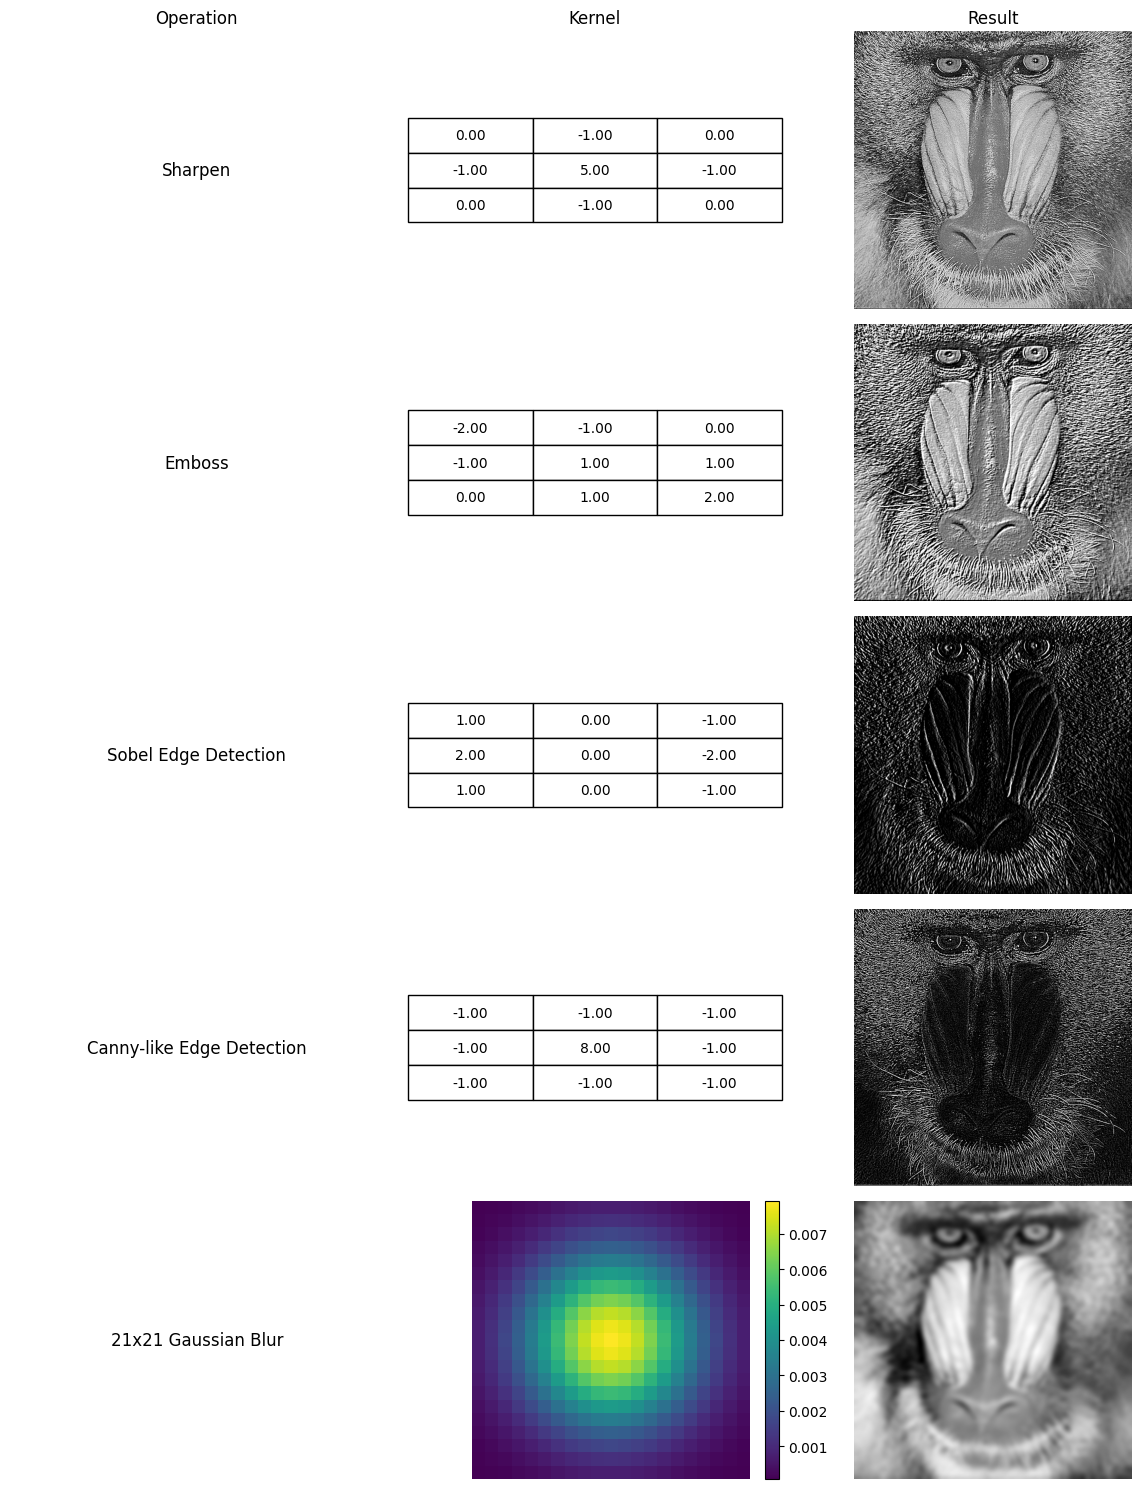

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# -------------------------
# Helper: Apply 2D convolution to an image using a given kernel
# -------------------------
def apply_filter(image, kernel):
    kernel = np.array(kernel, dtype=np.float32)
    return cv.filter2D(image, -1, kernel)

# -------------------------
# Helper: Visualize kernel either as table or heatmap
# -------------------------
def display_kernel(ax, kernel):
    kernel = np.array(kernel, dtype=np.float32)
    ax.axis("off")
    if kernel.size <= 25:  # For small kernels, show values as a table
        formatted_values = [[f"{val:.2f}" for val in row] for row in kernel]
        table = ax.table(cellText=formatted_values, loc="center", cellLoc="center")
        table.scale(1, 1.5)
    else:  # For large kernels, use a heatmap
        heatmap = ax.imshow(kernel, cmap="viridis", interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)

# -------------------------
# Load grayscale version of the image
# -------------------------
image_path = '/content/drive/MyDrive/PCVK/Images/mandrill.tiff'
image_bgr = cv.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Image not found at: {image_path}")

image_gray = cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)

# -------------------------
# Define various filter kernels
# -------------------------
# Sharpening filter
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32)

# Emboss effect kernel
emboss_kernel = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [0,   1, 2]], dtype=np.float32)

# Sobel edge detection (horizontal)
sobel_kernel = np.array([[1, 0, -1],
                         [2, 0, -2],
                         [1, 0, -1]], dtype=np.float32)

# Canny-like edge detection kernel
canny_kernel = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]], dtype=np.float32)

# Large 2D Gaussian blur kernel
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_col = cv.getGaussianKernel(kernel_size, sigma).astype(np.float32)
gaussian_kernel = (gaussian_col @ gaussian_col.T).astype(np.float32)

# -------------------------
# Apply each kernel to the grayscale image
# -------------------------
filtered_images = [
    apply_filter(image_gray, sharpen_kernel),
    apply_filter(image_gray, emboss_kernel),
    apply_filter(image_gray, sobel_kernel),
    apply_filter(image_gray, canny_kernel),
    apply_filter(image_gray, gaussian_kernel)
]

# -------------------------
# Prepare titles and kernel list for display
# -------------------------
filter_names = ["Sharpen", "Emboss", "Sobel Edge Detection",
                "Canny-like Edge Detection", "21x21 Gaussian Blur"]
kernels = [sharpen_kernel, emboss_kernel, sobel_kernel, canny_kernel, gaussian_kernel]

# -------------------------
# Plot: Operation | Kernel | Filtered Image
# -------------------------
rows = len(filtered_images)
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(12, 3 * rows))

for i in range(rows):
    # Column 1: Operation name
    op_ax = axes[i, 0]
    op_ax.axis("off")
    op_ax.text(0.5, 0.5, filter_names[i], fontsize=12, ha="center", va="center")
    if i == 0:
        op_ax.set_title("Operation")

    # Column 2: Kernel (either table or heatmap)
    kernel_ax = axes[i, 1]
    display_kernel(kernel_ax, kernels[i])
    if i == 0:
        kernel_ax.set_title("Kernel")

    # Column 3: Filtered result image
    result_ax = axes[i, 2]
    result_ax.imshow(filtered_images[i], cmap="gray")
    result_ax.axis("off")
    if i == 0:
        result_ax.set_title("Result")

plt.tight_layout()
plt.show()

## **Filter Library and Modern Filter**

### **Experiment 1 - Original, Gaussian Blur, Sharpened, Canny Edge Detection**

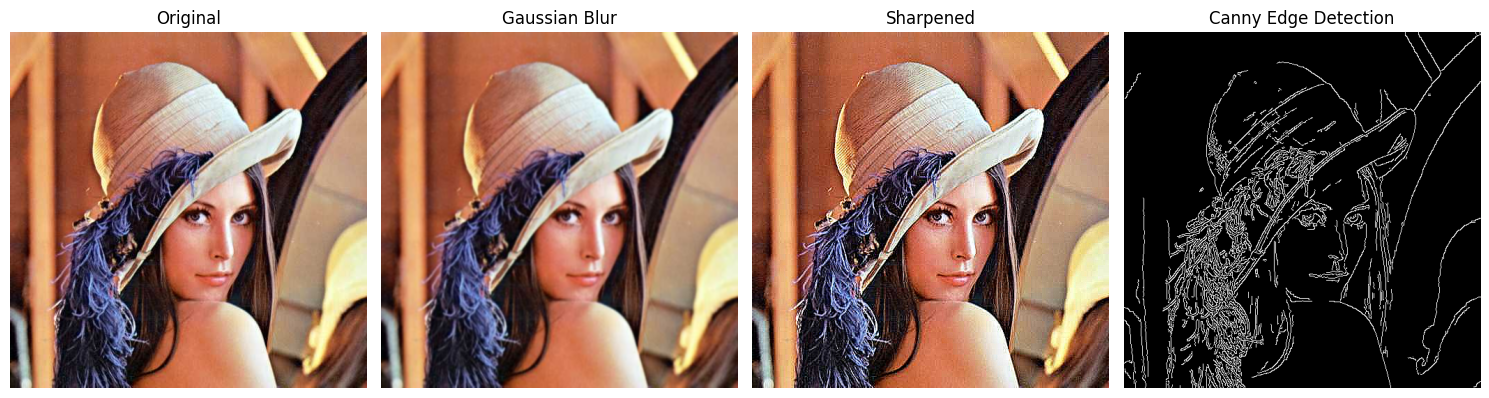

In [14]:
# -------------------------
# Utility: Display multiple images side by side with titles
# -------------------------
def display_images(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)

        # If the image is grayscale, use gray colormap
        if len(image.shape) == 2:
            plt.imshow(image, cmap="gray")
        else:
            # Convert BGR to RGB for proper display
            plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# -------------------------
# Load and prepare image
# -------------------------
image_path = "/content/drive/MyDrive/PCVK/Images/lena.jpg"
image_color = cv.imread(image_path)
image_gray = cv.cvtColor(image_color, cv.COLOR_BGR2GRAY)

# -------------------------
# Apply Gaussian Blur (smoothing filter)
# -------------------------
blurred_image = cv.GaussianBlur(image_color, (7, 7), sigmaX=1)

# -------------------------
# Apply Canny Edge Detection on grayscale image
# -------------------------
canny_edges = cv.Canny(image_gray, threshold1=100, threshold2=200)

# -------------------------
# Apply sharpening filter
# -------------------------
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32)
sharpened_image = cv.filter2D(image_color, -1, sharpen_kernel)

# -------------------------
# Show all processed images side by side
# -------------------------
display_images(
    [image_color, blurred_image, sharpened_image, canny_edges],
    ["Original", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)


### **Experiment 2 - Bilateral and Guided Filter**

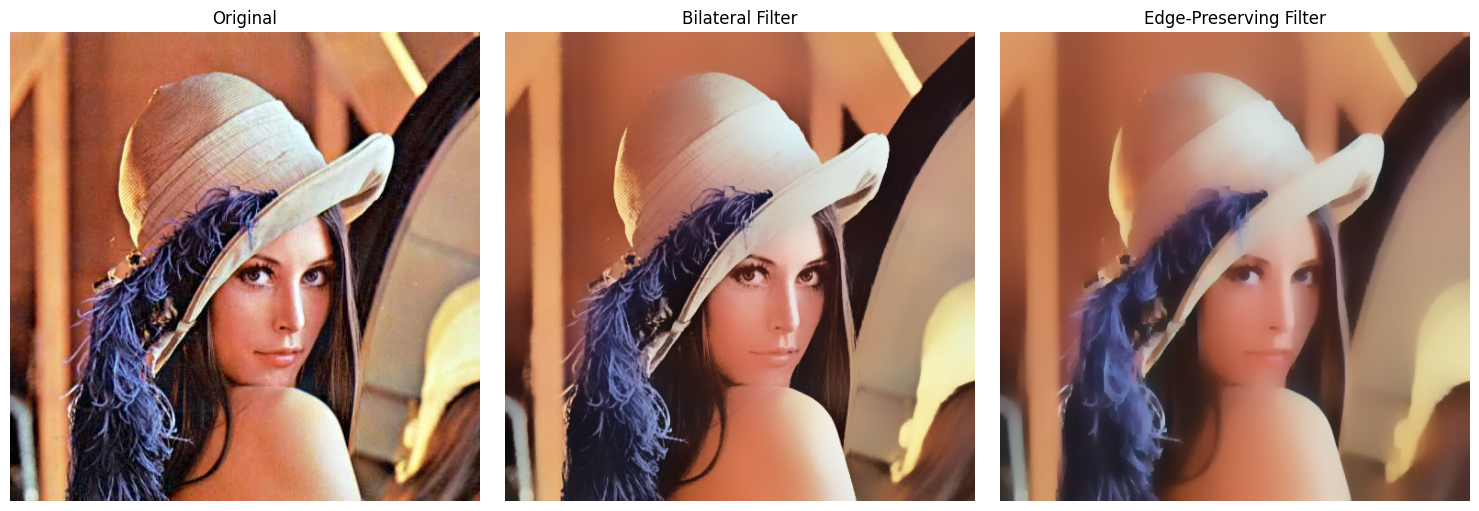

In [15]:
# -------------------------
# Apply Bilateral Filter
# -------------------------
# This filter smooths the image while preserving edges.
bilateral_filtered = cv.bilateralFilter(
    image_color, d=50, sigmaColor=100, sigmaSpace=100
)

# -------------------------
# Apply Edge-Preserving Filter
# -------------------------
# An alternative to guided filtering that maintains edges during smoothing.
edge_preserved = cv.edgePreservingFilter(
    image_color, flags=1, sigma_s=100, sigma_r=0.9
)

# -------------------------
# Display original and filtered results side by side
# -------------------------
display_images(
    [image_color, bilateral_filtered, edge_preserved],
    ["Original", "Bilateral Filter", "Edge-Preserving Filter"]
)

Conclusion : The application of the Bilateral Filter demonstrates that it can smooth out noise effectively while still maintaining sharp edges. Compared to Gaussian Blur, the Bilateral Filter is able to retain important structural details, making it highly useful in scenarios where edge preservation is critical, such as medical imaging or object recognition tasks.

### **Experiment 3 - Convolution**

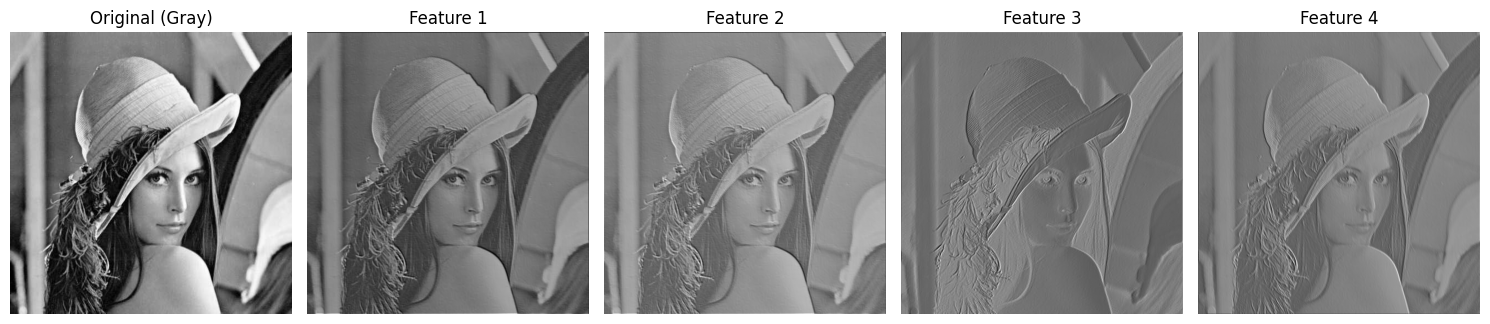

In [16]:
# -----------------------------
# Simple CNN: 1-layer convolution
# -----------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Define a single convolutional layer
        # Input: 1 channel (grayscale), Output: 4 feature maps
        # Kernel size: 3x3, stride: 1, padding: 1 (same size output)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        # Apply the convolution operation
        return self.conv1(x)


# -----------------------------
# Create an instance of the CNN model
# -----------------------------
model = SimpleCNN()

# -----------------------------
# Convert grayscale image to a normalized 4D tensor
# Shape: (1, 1, height, width) → required input for Conv2d
# Divide by 255 to normalize pixel values to [0, 1]
# -----------------------------
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# -----------------------------
# Perform forward pass (inference) without gradient tracking
# -----------------------------
with torch.no_grad():
    features = model(img_tensor)  # Output shape: (1, 4, H, W)

# -----------------------------
# Convert each feature map from tensor to NumPy array for visualization
# -----------------------------
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

# -----------------------------
# Show original grayscale image alongside its feature maps
# -----------------------------
show_side_by_side(
    [img_gray] + feature_maps,
    ["Original (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))]
)


### **Experiment 4 - Beauty Filter, Old Vintage Filter**

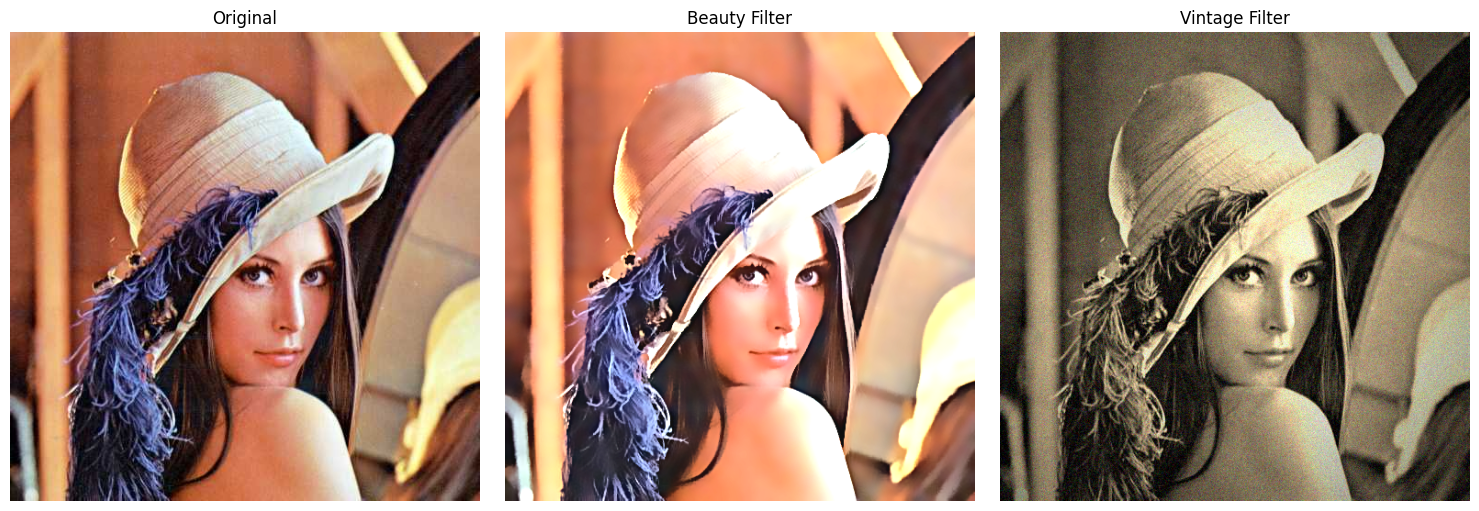

In [17]:
# =========================
# 1. Beauty Filter: Skin smoothing + sharpening + brightness enhancement
# =========================
def apply_beauty_filter(image, d=15, sigma_color=75, sigma_space=75, alpha=1.2, beta=15):
    # Step 1: Smooth the skin using a bilateral filter (preserves edges)
    smoothed = cv.bilateralFilter(image, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

    # Step 2: Enhance edges (e.g. eyes, lips) using unsharp masking
    blurred = cv.GaussianBlur(smoothed, (0, 0), sigmaX=3)
    enhanced = cv.addWeighted(smoothed, 1.5, blurred, -0.5, 0)

    # Step 3: Adjust brightness and contrast
    beautified = cv.convertScaleAbs(enhanced, alpha=alpha, beta=beta)

    return beautified

# =========================
# 2. Vintage Filter: Sepia tone + vignette + noise grain
# =========================
def apply_vintage_filter(image):
    # Step 1: Apply sepia color transformation
    sepia_kernel = np.array([
        [0.272, 0.534, 0.131],
        [0.349, 0.686, 0.168],
        [0.393, 0.769, 0.189]
    ])
    sepia = cv.transform(image, sepia_kernel)
    sepia = np.clip(sepia, 0, 255).astype(np.uint8)

    # Step 2: Create vignette mask using Gaussian kernels
    rows, cols = image.shape[:2]
    kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
    kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
    vignette_mask = kernel_y @ kernel_x.T
    vignette_mask /= vignette_mask.max()  # Normalize to [0, 1]

    vignette = sepia.copy()
    for channel in range(3):
        vignette[:, :, channel] = vignette[:, :, channel] * vignette_mask

    # Step 3: Add random noise (grain effect)
    noise = np.random.normal(loc=0, scale=15, size=vignette.shape).astype(np.int16)
    noisy_vintage = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return noisy_vintage

# =========================
# Apply Filters to Original Image
# =========================
beauty_result = apply_beauty_filter(image_color)
vintage_result = apply_vintage_filter(image_color)

# =========================
# Display Original and Filtered Images Side by Side
# =========================
display_images(
    [image_color, beauty_result, vintage_result],
    ["Original", "Beauty Filter", "Vintage Filter"]
)


### **Experiment 5 - Anime / Cartoon Filter**

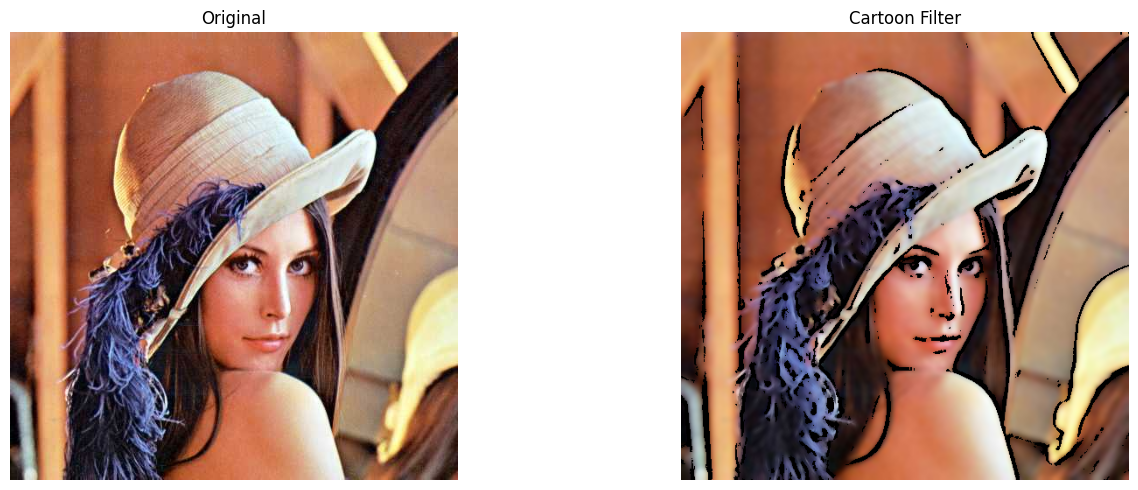

In [18]:
# =========================
# Cartoon Filter: Edge mask + color smoothing
# =========================
def apply_cartoon_filter(image, d=9, sigma_color=200, sigma_space=200):
    # Step 1: Edge detection on a smoothed grayscale image
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    blurred_gray = cv.medianBlur(gray, 7)  # Median blur helps reduce noise
    edge_mask = cv.adaptiveThreshold(
        blurred_gray, 255,
        adaptiveMethod=cv.ADAPTIVE_THRESH_MEAN_C,
        thresholdType=cv.THRESH_BINARY,
        blockSize=9,
        C=9
    )

    # Step 2: Bilateral filter for smooth, paint-like color effect
    smoothed_color = cv.bilateralFilter(
        image, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space
    )

    # Step 3: Combine smoothed color image with edge mask
    cartoon_output = cv.bitwise_and(smoothed_color, smoothed_color, mask=edge_mask)

    return cartoon_output

# =========================
# Apply Cartoon Filter
# =========================
cartoon_result = apply_cartoon_filter(image_color)

# =========================
# Display Original vs Cartoon Effect
# =========================
display_images(
    [image_color, cartoon_result],
    ["Original", "Cartoon Filter"]
)


### **Experiment 6 - Night Filter**

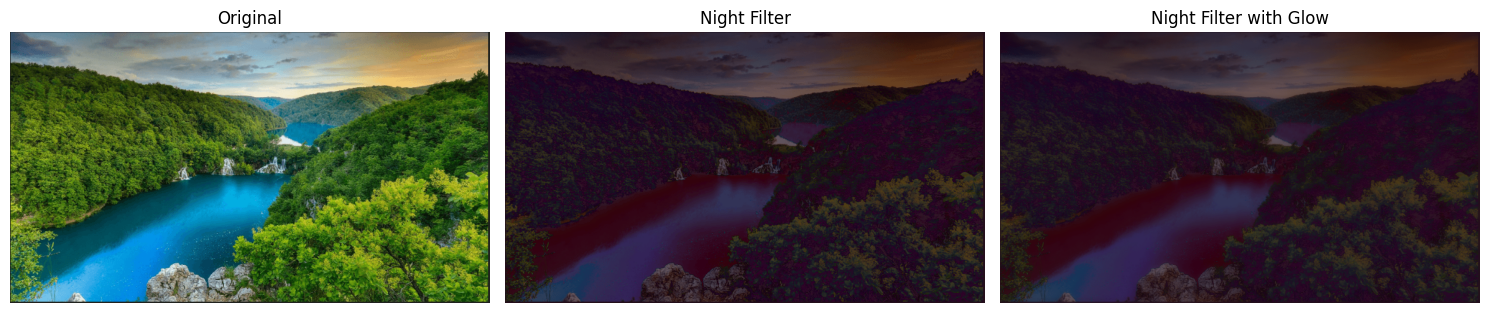

In [19]:
# =========================
# Night Filter with Blue Tint and Glow Effect
# =========================
def apply_night_filter(image, alpha=0.6, beta=-40, blue_bias=(50, 0, 100), glow_kernel_size=15):
    # Step 1: Darken the image (simulate low-light)
    darkened = cv.convertScaleAbs(image, alpha=alpha, beta=beta)

    # Step 2: Apply a blue-purple tint to mimic night ambiance
    tint = np.full_like(darkened, blue_bias)
    tinted = cv.addWeighted(darkened, 0.8, tint, 0.2, 0)

    # Step 3: Apply a blur kernel to simulate soft glow
    glow_kernel = np.ones((glow_kernel_size, glow_kernel_size), dtype=np.float32) / 225
    blurred = cv.filter2D(tinted, -1, glow_kernel)

    # Step 4: Blend original night image with glow
    night_with_glow = cv.addWeighted(tinted, 0.7, blurred, 0.3, 0)

    return tinted, night_with_glow

# =========================
# Load Image
# =========================
image = cv.imread('/content/drive/MyDrive/PCVK/Images/jungle.png')
image_gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# =========================
# Apply Night Filter
# =========================
night_result, night_with_glow_result = apply_night_filter(image)

# =========================
# Display Results
# =========================
result_images = [image, night_result, night_with_glow_result]
titles = ["Original", "Night Filter", "Night Filter with Glow"]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(cv.cvtColor(result_images[i], cv.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


### **Experiment 7 - Morning and Fog Filters**

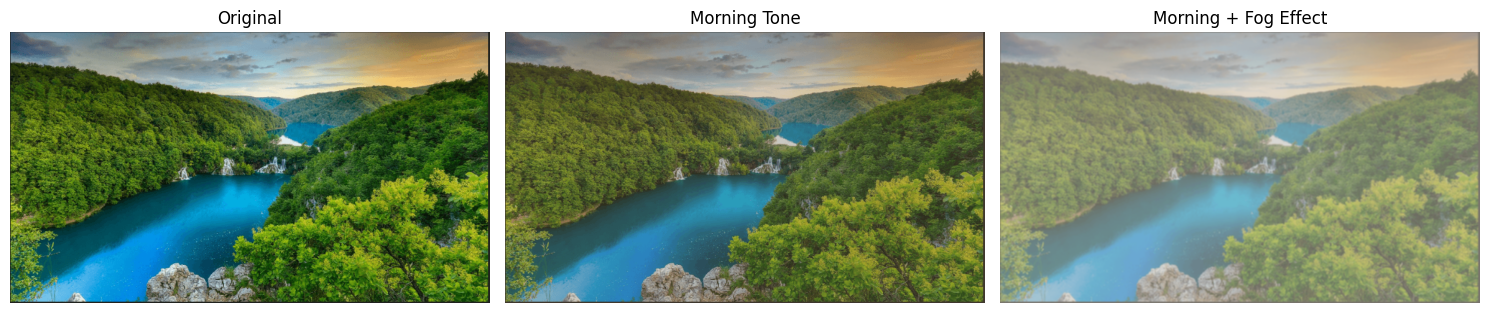

In [20]:
# =========================
# Morning Fog Filter: Warm tone + brightness + foggy overlay
# =========================
def apply_morning_fog_filter(image, alpha=0.9, beta=20, warm_tone=(40, 70, 120)):
    # Step 1: Brighten and soften image by lowering contrast slightly
    softened = cv.convertScaleAbs(image, alpha=alpha, beta=beta)

    # Step 2: Apply warm tint (orangish morning tone)
    warm_overlay = np.full_like(softened, warm_tone)
    morning_toned = cv.addWeighted(softened, 0.8, warm_overlay, 0.2, 0)

    # Step 3: Create subtle fog effect using Gaussian blur
    blur_kernel = cv.getGaussianKernel(3, 3)
    foggy = cv.filter2D(morning_toned, -1, blur_kernel @ blur_kernel.T)

    # Step 4: Add a translucent white layer to simulate morning haze
    white_fog = np.full_like(morning_toned, 255)
    fog_with_overlay = cv.addWeighted(foggy, 0.7, white_fog, 0.3, 0)

    return morning_toned, fog_with_overlay

# =========================
# Apply the Filter
# =========================
morning_result, foggy_result = apply_morning_fog_filter(image)

# =========================
# Display Results Side by Side
# =========================
display_images(
    [image, morning_result, foggy_result],
    ["Original", "Morning Tone", "Morning + Fog Effect"]
)
